In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [73]:
# Phase 1 — Define dataset paths

TRADER_DATA_PATH = "../data/historical_data.csv"
SENTIMENT_DATA_PATH = "../data/fear_greed_index.csv"

print("Paths Defined")

Paths Defined


In [74]:
# Phase 2 — Load datasets

trader_data = pd.read_csv(TRADER_DATA_PATH)
sentiment_data = pd.read_csv(SENTIMENT_DATA_PATH)

print("Datasets Loaded Successfully")


Datasets Loaded Successfully


In [75]:
# View first rows of trader dataset
print("Trader Dataset Preview")
display(trader_data.head())

# View first rows of sentiment dataset
print("Sentiment Dataset Preview")
display(sentiment_data.head())

Trader Dataset Preview


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


Sentiment Dataset Preview


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [76]:
print("Trader Dataset Shape:", trader_data.shape)
print("Sentiment Dataset Shape:", sentiment_data.shape)

Trader Dataset Shape: (211224, 16)
Sentiment Dataset Shape: (2644, 4)


In [77]:
print("Trader Dataset Info")
trader_data.info()

print("\nSentiment Dataset Info")
sentiment_data.info()

Trader Dataset Info
<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  str    
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  str    
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1),

In [78]:
print("Missing Values in Trader Dataset:")
print(trader_data.isnull().sum())

print("\nMissing Values in Sentiment Dataset:")
print(sentiment_data.isnull().sum())

Missing Values in Trader Dataset:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Missing Values in Sentiment Dataset:
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [79]:
print("Duplicate Rows in Trader Dataset:", trader_data.duplicated().sum())
print("Duplicate Rows in Sentiment Dataset:", sentiment_data.duplicated().sum())

Duplicate Rows in Trader Dataset: 0
Duplicate Rows in Sentiment Dataset: 0


In [80]:
# Phase 3 — Convert timestamp to datetime

trader_data['Timestamp'] = pd.to_datetime(trader_data['Timestamp'], unit='ms')

trader_data[['Timestamp']].head()

,Timestamp
0,2024-10-27 03:33:20
1,2024-10-27 03:33:20
2,2024-10-27 03:33:20
3,2024-10-27 03:33:20
4,2024-10-27 03:33:20


In [81]:
# Extract trade date

trader_data['trade_date'] = trader_data['Timestamp'].dt.date

trader_data[['Timestamp','trade_date']].tail()

,Timestamp,trade_date
211219,2025-06-15 15:06:40,2025-06-15
211220,2025-06-15 15:06:40,2025-06-15
211221,2025-06-15 15:06:40,2025-06-15
211222,2025-06-15 15:06:40,2025-06-15
211223,2025-06-15 15:06:40,2025-06-15


In [82]:
# Convert sentiment date to datetime

sentiment_data['date'] = pd.to_datetime(sentiment_data['date']).dt.date

sentiment_data.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [83]:
# Keep only important columns

sentiment_data = sentiment_data[['date','classification']]

sentiment_data.head()

,date,classification
0,2018-02-01,Fear
1,2018-02-02,Extreme Fear
2,2018-02-03,Fear
3,2018-02-04,Extreme Fear
4,2018-02-05,Extreme Fear


In [84]:
print("Trader Dataset Info After Cleaning")
trader_data.info()

print("\nSentiment Dataset Info After Cleaning")
sentiment_data.info()

Trader Dataset Info After Cleaning
<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  str           
 1   Coin              211224 non-null  str           
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  str           
 6   Timestamp IST     211224 non-null  str           
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  str           
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  str           
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  

In [85]:
print("Cleaned Trader Dataset")
display(trader_data.head())

print("Cleaned Sentiment Dataset")
display(sentiment_data.head())

Cleaned Trader Dataset


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,trade_date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27


Cleaned Sentiment Dataset


,date,classification
0,2018-02-01,Fear
1,2018-02-02,Extreme Fear
2,2018-02-03,Fear
3,2018-02-04,Extreme Fear
4,2018-02-05,Extreme Fear


In [86]:
# Phase 4 — Merge trader data with sentiment data

merged_data = pd.merge(
    trader_data,
    sentiment_data,
    left_on='trade_date',
    right_on='date',
    how='left'
)

print("Datasets merged successfully")

Datasets merged successfully


In [87]:
merged_data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,trade_date,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,2024-10-27,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,2024-10-27,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,2024-10-27,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,2024-10-27,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,2024-10-27,Greed


In [88]:
# Check Merge Success
print(merged_data['classification'].value_counts())

# Check Missing Sentiment Values
print("Missing Sentiment Values:",merged_data['classification'].isnull().sum())


print("Merged Dataset Shape:", merged_data.shape)

classification
Fear             133871
Greed             36289
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64
Missing Sentiment Values: 26961
Merged Dataset Shape: (211224, 19)


In [89]:
# View Important Columns

merged_data[
    [
        'Account',
        'Coin',
        'Side',
        'Size USD',
        'Closed PnL',
        'trade_date',
        'classification'
    ]
].head()

,Account,Coin,Side,Size USD,Closed PnL,trade_date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,7872.16,0.0,2024-10-27,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,127.68,0.0,2024-10-27,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,1150.63,0.0,2024-10-27,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,1142.04,0.0,2024-10-27,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,69.75,0.0,2024-10-27,Greed


In [90]:
merged_data.to_csv("../data/merged_trader_sentiment_data.csv", index=False)

print("Merged dataset saved")

Merged dataset saved


In [91]:
# Phase 5 — Remove rows with missing sentiment

merged_data = merged_data.dropna(subset=['classification'])

print("Remaining rows:", merged_data.shape)

Remaining rows: (184263, 19)


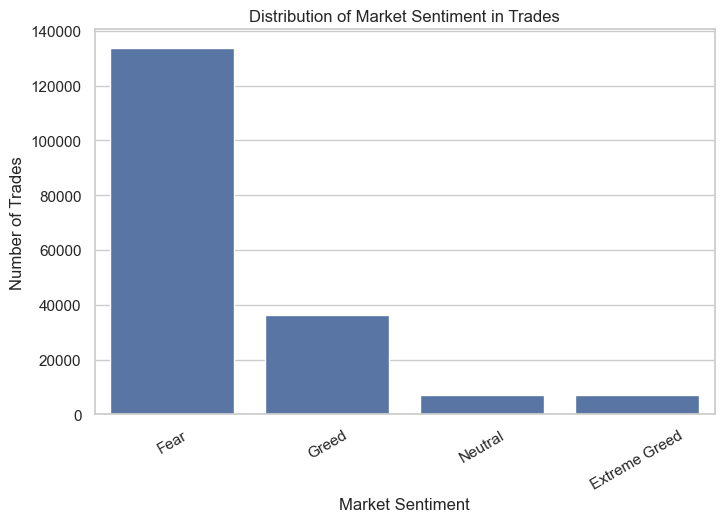

In [92]:
# Sentiment Distribution

plt.figure(figsize=(8,5))

sns.countplot(data=merged_data, x='classification', order=merged_data['classification'].value_counts().index)

plt.title("Distribution of Market Sentiment in Trades")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.xticks(rotation=30)
plt.savefig("../images/1.sentiment_distribution.png", bbox_inches="tight")
plt.show()

In [93]:
profit_by_sentiment = merged_data.groupby('classification')['Closed PnL'].mean()

print(profit_by_sentiment)

classification
Extreme Greed    25.418772
Fear             50.047622
Greed            87.894859
Neutral          22.229713
Name: Closed PnL, dtype: float64


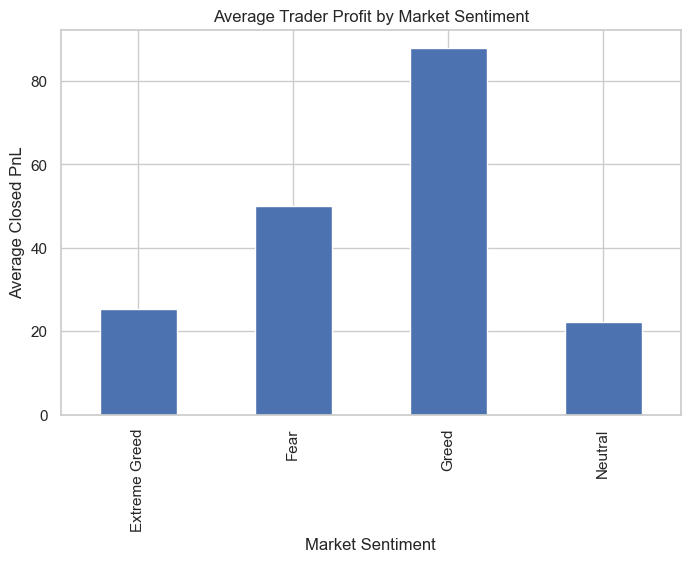

In [94]:
# Profit vs Market Sentiment

profit_by_sentiment.plot(kind='bar', figsize=(8,5))

plt.title("Average Trader Profit by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.savefig("../images/2.profit_by_sentiment.png", bbox_inches="tight")

plt.show()

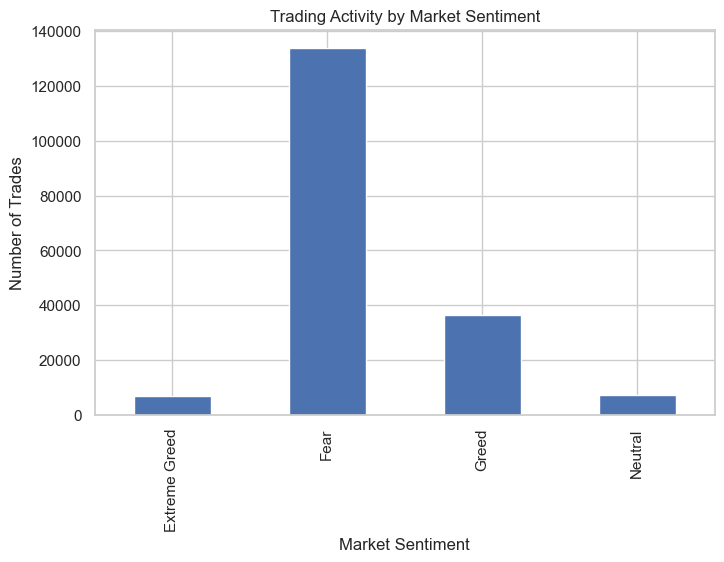

In [95]:
# Trading Activity vs Sentiment

trade_activity = merged_data.groupby('classification').size()

trade_activity.plot(kind='bar', figsize=(8,5))

plt.title("Trading Activity by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.savefig("../images/3.trade_activity_by_sentiment.png", bbox_inches="tight")

plt.show()

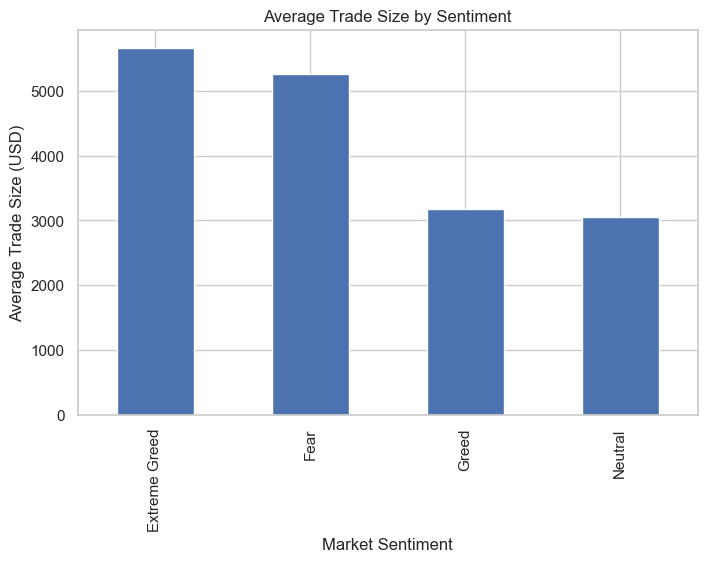

In [96]:
# Trade Size vs Sentiment

trade_size = merged_data.groupby('classification')['Size USD'].mean()

trade_size.plot(kind='bar', figsize=(8,5))

plt.title("Average Trade Size by Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")
plt.savefig("../images/4.trade_size_by_sentiment.png", bbox_inches="tight")

plt.show()

In [97]:
# Win Rate Analysis

merged_data['profit_flag'] = merged_data['Closed PnL'].apply(
    lambda x: 'Profit' if x > 0 else 'Loss'
)


In [98]:
win_rate = merged_data.groupby('classification')['profit_flag'].value_counts(normalize=True).unstack()

print(win_rate)

profit_flag         Loss    Profit
classification                    
Extreme Greed   0.509911  0.490089
Fear            0.584854  0.415146
Greed           0.553529  0.446471
Neutral         0.682818  0.317182


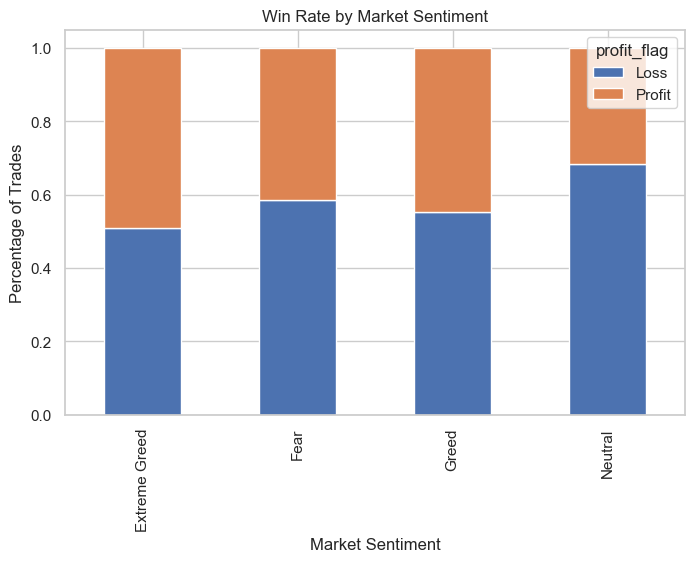

In [99]:
# Now plotting win rate 
win_rate.plot(kind='bar', stacked=True, figsize=(8,5))

plt.title("Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Percentage of Trades")
plt.savefig("../images/5.win_rate_by_sentiment.png", bbox_inches="tight")

plt.show()

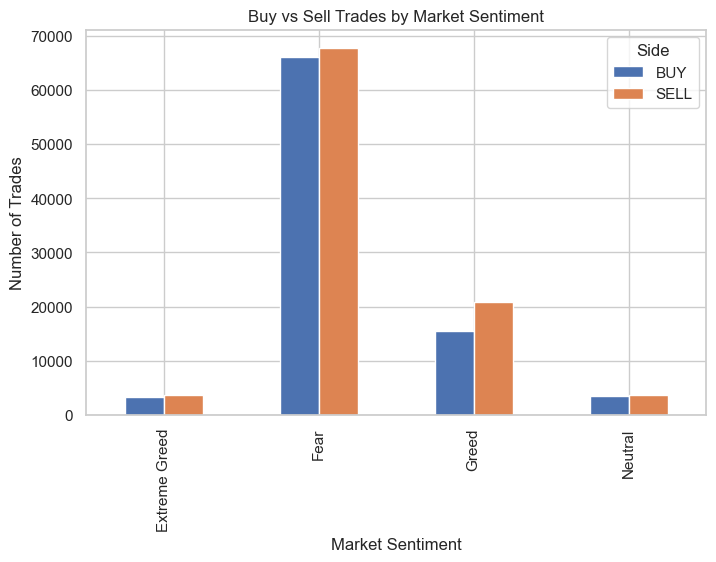

In [100]:
# Buy vs Sell Behavior

buy_sell = merged_data.groupby(['classification','Side']).size().unstack()

buy_sell.plot(kind='bar', figsize=(8,5))

plt.title("Buy vs Sell Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.savefig("../images/6.buy_sell_by_sentiment.png", bbox_inches="tight")

plt.show()

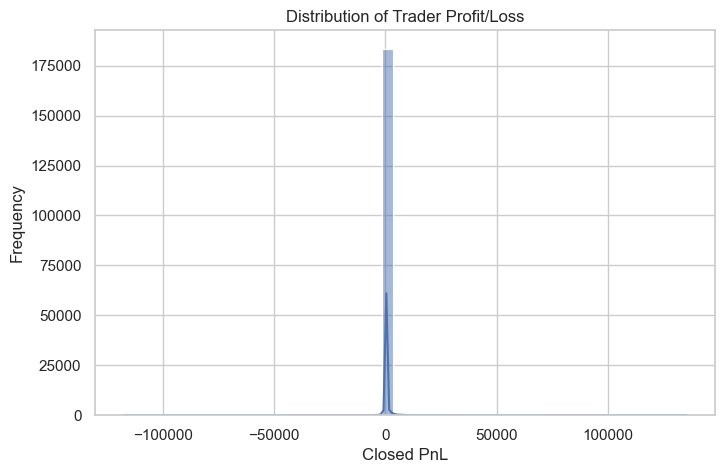

In [101]:
# Profit Distribution

plt.figure(figsize=(8,5))

sns.histplot(merged_data['Closed PnL'], bins=50, kde=True)

plt.title("Distribution of Trader Profit/Loss")
plt.xlabel("Closed PnL")
plt.ylabel("Frequency")
plt.savefig("../images/7.profit_distribution.png", bbox_inches="tight")

plt.show()

In [102]:
# Phase 6 — Top profitable traders

top_traders = merged_data.groupby('Account')['Closed PnL'].sum().sort_values(ascending=False).head(10)

print("Top 10 Most Profitable Traders")
print(top_traders)

Top 10 Most Profitable Traders
Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.040922e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401572e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.111830e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.744040e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.258152e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    4.035016e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    3.936830e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.615766e+05
Name: Closed PnL, dtype: float64


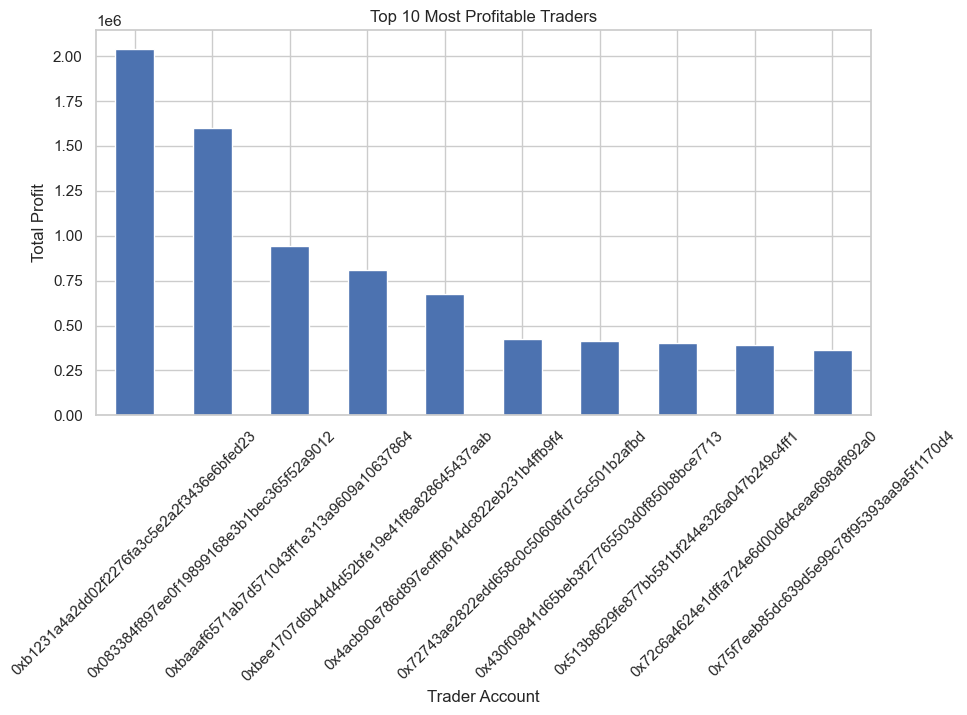

In [103]:
# Visualize Top Traders

plt.figure(figsize=(10,5))

top_traders.plot(kind='bar')

plt.title("Top 10 Most Profitable Traders")
plt.xlabel("Trader Account")
plt.ylabel("Total Profit")

plt.xticks(rotation=45)
plt.savefig("../images/8.profitable_traders.png", bbox_inches="tight")

plt.show()

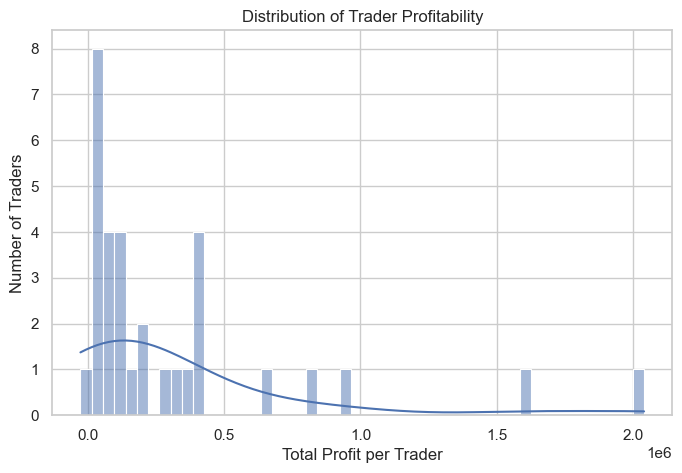

In [104]:
# Profitability Distribution Across Traders

trader_profit = merged_data.groupby('Account')['Closed PnL'].sum()

plt.figure(figsize=(8,5))

sns.histplot(trader_profit, bins=50, kde=True)

plt.title("Distribution of Trader Profitability")
plt.xlabel("Total Profit per Trader")
plt.ylabel("Number of Traders")
plt.savefig("../images/9.profitability_distribution.png", bbox_inches="tight")

plt.show()

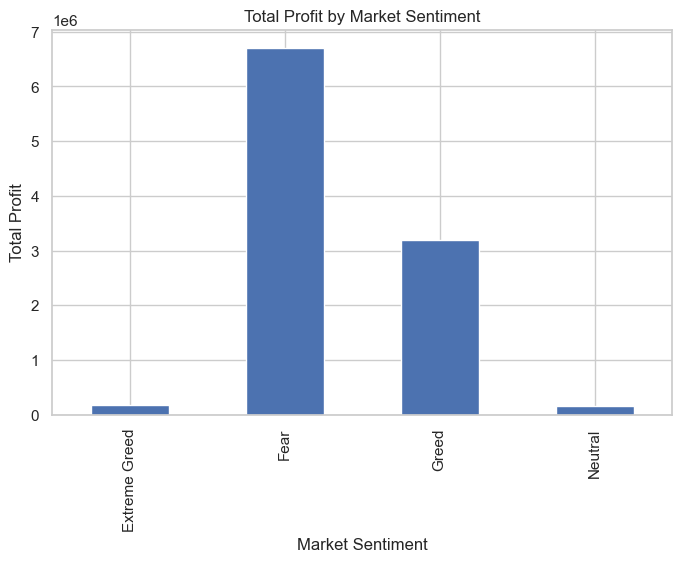

In [105]:
# Trader Performance by Sentiment

sentiment_profit = merged_data.groupby('classification')['Closed PnL'].sum()

sentiment_profit.plot(kind='bar', figsize=(8,5))

plt.title("Total Profit by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Total Profit")
plt.savefig("../images/10.trader_performance_by_sentiment.png", bbox_inches="tight")

plt.show()

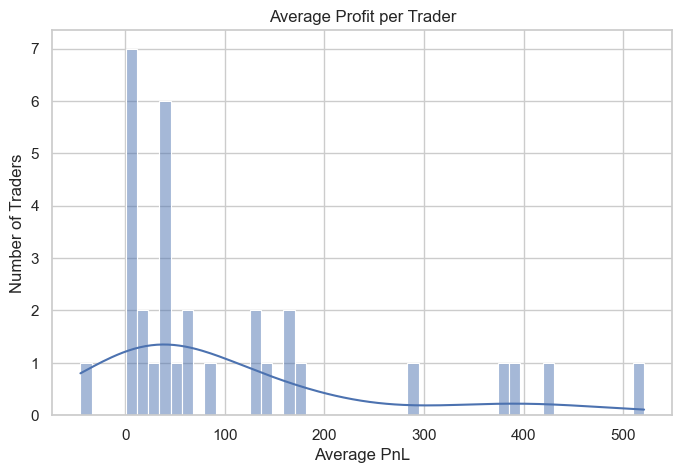

In [106]:
# Average Profit per Trader

avg_trader_profit = merged_data.groupby('Account')['Closed PnL'].mean()

plt.figure(figsize=(8,5))

sns.histplot(avg_trader_profit, bins=50, kde=True)

plt.title("Average Profit per Trader")
plt.xlabel("Average PnL")
plt.ylabel("Number of Traders")

plt.show()

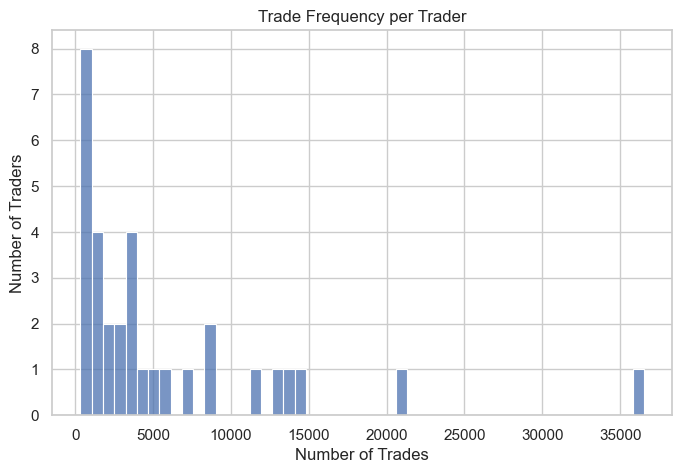

In [107]:
# Trade Frequency per Trader

trade_frequency = merged_data['Account'].value_counts()

plt.figure(figsize=(8,5))

sns.histplot(trade_frequency, bins=50)

plt.title("Trade Frequency per Trader")
plt.xlabel("Number of Trades")
plt.ylabel("Number of Traders")
plt.savefig("../images/11.trade_frequency.png", bbox_inches="tight")

plt.show()

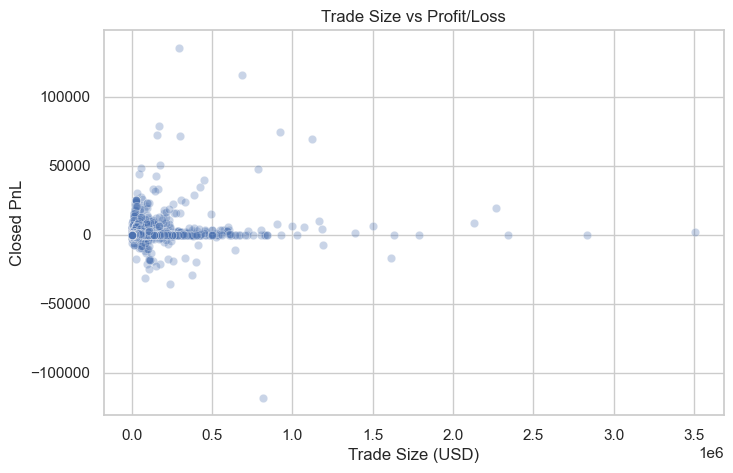

In [108]:
# Trade Size vs Profit

plt.figure(figsize=(8,5))

sns.scatterplot(data=merged_data, x='Size USD', y='Closed PnL', alpha=0.3)

plt.title("Trade Size vs Profit/Loss")
plt.xlabel("Trade Size (USD)")
plt.ylabel("Closed PnL")
plt.savefig("../images/12.trade_size_vs_profit.png", bbox_inches="tight")

plt.show()

In [109]:
# Phase 7 — Insights Summary Table

summary_table = pd.DataFrame({
    "Analysis Area": [
        "Most Common Market Sentiment",
        "Highest Average Profit Sentiment",
        "Highest Trading Activity",
        "Largest Average Trade Size",
        "Most Active Traders"
    ],
    
    "Observation": [
        merged_data['classification'].value_counts().idxmax(),
        merged_data.groupby('classification')['Closed PnL'].mean().idxmax(),
        merged_data['classification'].value_counts().idxmax(),
        merged_data.groupby('classification')['Size USD'].mean().idxmax(),
        merged_data['Account'].value_counts().idxmax()
    ]
})

summary_table

,Analysis Area,Observation
0,Most Common Market Sentiment,Fear
1,Highest Average Profit Sentiment,Greed
2,Highest Trading Activity,Fear
3,Largest Average Trade Size,Extreme Greed
4,Most Active Traders,0xbee1707d6b44d4d52bfe19e41f8a828645437aab


## Executive Summary

This project analyzed the relationship between cryptocurrency trader behavior and Bitcoin market sentiment using historical trading data and the Fear & Greed Index.

Key findings indicate that market sentiment significantly influences trader behavior. Trading activity and trade sizes tend to increase during Greed market conditions, while Fear periods often show lower profitability. Additionally, the analysis reveals that a small number of traders contribute a large portion of overall profits.

These insights demonstrate how sentiment indicators can be useful in understanding trading patterns and designing more informed trading strategies.

## Final Insights

Based on the analysis of trader activity and Bitcoin market sentiment, several key patterns were identified.

Final Insights

Based on the analysis of trader activity and Bitcoin market sentiment, several key patterns were identified.

1. Market Sentiment Distribution

Most trades occurred during Fear market conditions, followed by Greed. This suggests that traders remain active even during uncertain or pessimistic market periods.

2. Trader Profitability and Sentiment

Average trader profitability tends to increase during Greed market periods compared to Fear periods, indicating that bullish market sentiment creates more profitable trading opportunities.

3. Trading Activity Patterns

Trading activity is highest during Fear sentiment, suggesting that traders may attempt to react quickly during volatile or uncertain market conditions.

4. Trade Size Behavior

Average trade sizes are larger during Extreme Greed and Fear, indicating that traders take larger positions during strong emotional market phases.

5. Trader Profit Distribution

The profit distribution shows that most trades cluster around small profit or loss values, while only a few trades generate extremely large gains or losses.

6. Trade Frequency Patterns

Trade frequency analysis shows that a small number of traders execute very large numbers of trades, while the majority of traders participate much less frequently.

7. Trade Size and Profit Relationship

The scatter plot between trade size and profit shows high variability, meaning larger trades do not always guarantee higher profits and can also lead to large losses.

8. Win Rate Differences Across Sentiments

Win rate analysis shows that Greed sentiment has a higher proportion of profitable trades compared to Fear and Neutral conditions, suggesting market optimism improves trade success rates.

9. Buy vs Sell Behavior

Across most sentiment categories, sell trades slightly exceed buy trades, indicating traders may be frequently closing positions or hedging risk during uncertain markets.

10. Profit Contribution by Sentiment

Although Fear has the highest number of trades, total profit contribution is also significantly high during Greed periods, indicating that profitable opportunities increase when the market becomes optimistic.

11. Presence of Highly Profitable Traders

The top trader analysis shows that a small group of traders generates extremely large cumulative profits, suggesting that experience or advanced strategies play a major role in profitability.

12. Profitability Inequality Among Traders

The profitability distribution indicates that most traders earn relatively small profits while only a few achieve very large gains, highlighting the uneven nature of trading performance in crypto markets.

## Conclusion

This analysis explored the relationship between trader performance and Bitcoin market sentiment using historical trading data and the Fear & Greed Index.

The results indicate that market sentiment plays an important role in trader behavior and profitability. Traders tend to take larger positions and generate higher profits during Greed market conditions, while Fear markets often show lower profitability.

Additionally, trading activity varies significantly across sentiment conditions, and profit distribution suggests that only a small percentage of traders consistently achieve large profits.

These findings highlight the importance of market sentiment as a factor influencing trading strategies and trader performance in cryptocurrency markets.

# Final Notebook Structure

1. Introduction
2. Data Loading
3. Data Cleaning
4. Data Merging
5. Exploratory Data Analysis
6. Advanced Trader Analysis
7. Final Insights
8. Conclusion